## Topic Modeling

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.model_selection import train_test_split

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

import pyLDAvis
import pyLDAvis.lda_model

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Load the Data

In [3]:
CSV_PATH = "/Users/alexandraflores/Desktop/movie_reviews_clean_2000.csv"

In [5]:
import contractions 

#read file 
df = pd.read_csv(CSV_PATH)

#fix contractions
df['topic_text'] = df['clean_reviews'].apply(lambda x: contractions.fix(x))

REQUIRED_COLS = ["clean_movie_name", "topic_text", "clean_genre",
                  "clean_description", "emotion"]
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    print("Warning — missing expected columns:", missing)

# Drop rows with no usable text
df = df.dropna(subset=["topic_text"]).reset_index(drop=True)
df = df[df["topic_text"].str.strip().str.len() > 0].reset_index(drop=True)

print(f"{len(df):,} listings with usable text")
df[["topic_text"]].head(3)

2,000 listings with usable text


,topic_text
0,i wish there were more comedies like that - cr...
1,for a film that is strangely underwhelming and...
2,comic book violence with gleaming visuals apar...


## Clean Data More

In [6]:
#remove names and fix contractions on data
import spacy
import contractions

nlp = spacy.load("en_core_web_sm")  

def remove_entities(text):
    if not isinstance(text, str):
        return text
    doc = nlp(text)
    return " ".join([token.text for token in doc 
                      if token.ent_type_ not in ("PERSON", "ORG", "GPE", "WORK_OF_ART")])

df = pd.read_csv(CSV_PATH)

# Step 1: fix contractions 
df['topic_text'] = df['clean_reviews'].apply(lambda x: contractions.fix(x) if isinstance(x, str) else x)

# Step 2: remove names/entities
df['topic_text'] = df['topic_text'].apply(remove_entities)

In [7]:

import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import nltk
nltk.download('names')

[nltk_data] Downloading package names to
[nltk_data]     /Users/alexandraflores/nltk_data...
[nltk_data]   Package names is already up-to-date!


True

### Clean even more... Remove Names

In [8]:
#remove names using this function bc the other one only works on raw data 
from nltk.corpus import names

all_names = set(n.lower() for n in names.words())

def strip_known_names(text):
    return " ".join([w for w in text.split() if w.lower() not in all_names])

df['topic_text'] = df['topic_text'].apply(strip_known_names)

In [9]:
sample = df['topic_text'].iloc[0]
print(sample[:500])

i wish there were more comedies like that - crossing over the political correctness line , but not over the line of good taste , so as to make a movie hard to watch.the film is quite pointy , it is for a moderate audience and make all kinds of extremists quite unhappy . the plot is well thought out and funny . it nail you to the screen.i like the unorthodox character of this film , movies are definitely one of the kind . i would not consider the humor crude , but it is certainly honest . some of


In [10]:
df["topic_text"].head()

0    i wish there were more comedies like that - cr...
1    for a film that is strangely underwhelming and...
2    comic book violence with gleaming visuals apar...
3    movies in the 80 's were really cool , nice st...
4    is funny and charming in a believably nerdy fa...
Name: topic_text, dtype: object

In [11]:
# Tokenized version of the corpus — reused by every coherence calculation below,
# so every model is scored against the exact same word co-occurrence statistics.
tokenized_docs = [doc.split() for doc in df["topic_text"]]
dictionary = Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=10, no_above=0.90)
print(f"Vocabulary after filtering: {len(dictionary):,} terms")

Vocabulary after filtering: 3,179 terms


## Shared Evaluation Helpers

In [12]:
def get_top_words(components, feature_names, n_top_words=10):
    """Top-N words per topic/component row, descending by weight."""
    top_words = []
    for row in components:
        top_idx = row.argsort()[-n_top_words:][::-1]
        top_words.append([feature_names[i] for i in top_idx])
    return top_words


def coherence_c_v(top_words, texts=tokenized_docs, dictionary=dictionary):
    """Gensim c_v coherence, averaged across topics. Higher is better."""
    cm = CoherenceModel(topics=top_words, texts=texts, dictionary=dictionary,
                         coherence="c_v")
    return cm.get_coherence()


def topic_diversity(top_words):
    """Fraction of top words that are unique across all topics. Higher is better."""
    all_words = [w for topic in top_words for w in topic]
    return len(set(all_words)) / len(all_words)


def redundant_pairs(top_words, overlap_threshold=5):
    """Flag topic pairs sharing >= overlap_threshold of their top words — the
    redundancy check from the Common Pitfalls section."""
    flags = []
    for i in range(len(top_words)):
        for j in range(i + 1, len(top_words)):
            shared = set(top_words[i]) & set(top_words[j])
            if len(shared) >= overlap_threshold:
                flags.append((i, j, sorted(shared)))
    return flags


def representative_docs(doc_topic_matrix, topic_idx, texts, top_n=3):
    """Top-N documents by weight on a given topic, as used for slide-15-style checks."""
    order = np.argsort(doc_topic_matrix[:, topic_idx])[::-1][:top_n]
    return [(texts[i], doc_topic_matrix[i, topic_idx]) for i in order]

### LDA

In [13]:
import random
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gensim.models import CoherenceModel
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
)
from sklearn.model_selection import train_test_split

# Add domain-specific words that appear frequently but do not help distinguish
# meaningful topics.

actor_stopwords = {
    'edward', 'twilight', 'gibson', 'hanks', 'li', 'van', 'damme', 'jean',
    'graham', 'stiller', 'alex', 'ben', 'morgan', 'robin', 'julia', 'patrick',
    'cruise', 'mary', 'julie', 'george', 'brown', 'michael', 'allen', 'tom',
    'khan', 'scarlett', 'martin', 'murphy', 'steve', 'cage', 'shrek', 'woody','sandler', 'adam', 'hepburn', 'roberts', 'leslie', 'mann', 
                          'carrie', 'eddie', 'dave', 'jack', 'tim', 'john'
}
domain_stopwords = set(ENGLISH_STOP_WORDS).union(actor_stopwords).union(
    [  'just', 'does', 'did', 'don', 'didn', 've', 'll', 'isn', 'wasn', 'doesn','overall','later'
    'movie', 'film', 'movies', 'films', 'really', 'like', 'good', 'bad',
    'felt', 'went', 'said', 'oh''just','does','did','movie', 'film','like','really','much','half','reason','oh','main','expecting'
    'would','could','well','way','movies','films','one','good','make','even','made','also','get',
    'think','see','many','go','know','better','character','characters','say','never','still','story','watched',
    'watching','plot','acting','actor','got','much','way','thing','time','scenes','going','lot','though','scene','something','nothing',
    'seen','almost','give','things','makes','enough','definitely','probably','always','another','actually','actors','end','every','two','first',
    'watch','cast','actors','people','ever','want','instead','seem','role','play','cast','without','seeing','find','little','new','real','thought','big',
    'quite','however','script','work','performance','ca','take','original','director','us','back','seems','may','bit','anything','show','completely','least',
    'look','come','feel','done','keep','looking','making','although','goes','comedy','great','bad','right','part','best','fun','good','old','young','everything',
    'life','job','saw','yet','great','screen','gets','year','especially','help','genre','bad','fan','right','excellent','expect','point','line','mind','man','come',
    'look','problem','year','enjoyed','fact','best','pretty','day','one','two','three','years','found','sense','minutes','played','everyone','laught','enjoy','world',
    'long','far','times','since','might','course','guy','throughout','together','girl','kind','moments','simply','audience','around','long','nice','hard','whole','trying',
    'last','must','comedy','romance','action','comedies','drama','fantasy','let', 'having', 'away', 'yes', 'need', 'getting', 
    'maybe', 'sure', 'told', 'turn', 'repeatedly', 'compare']
)

count_vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=10,
    stop_words=list(domain_stopwords),
    token_pattern=r"\b[a-zA-Z]{2,}\b",
)

# Split the raw text before fitting the vectorizer so the held-out vocabulary
# does not influence the training representation.
text_train, text_test = train_test_split(
    df["topic_text"],
    test_size=0.20,
    random_state=RANDOM_STATE,
)

# LDA uses raw word counts, not TF-IDF.
X_counts_train = count_vectorizer.fit_transform(text_train)
X_counts_test = count_vectorizer.transform(text_test)

count_terms = count_vectorizer.get_feature_names_out()

print("Training count matrix:", X_counts_train.shape)
print("Held-out count matrix:", X_counts_test.shape)
print("Vocabulary size:", len(count_terms))

Training count matrix: (1600, 2228)
Held-out count matrix: (400, 2228)
Vocabulary size: 2228


## LDA hyperparameter

In [14]:
# Hold the priors constant across candidate values of K. This means the grid
# comparison primarily reflects changes in the number of topics rather than
# simultaneous changes in K, alpha, and eta.

DOC_TOPIC_PRIOR = 0.10
TOPIC_WORD_PRIOR = 0.01

# Number of top words used for topic interpretation and evaluation.
N_TOP_WORDS = 10

In [15]:
# Use a fixed sample for every candidate K so coherence scores are comparable.
random.seed(RANDOM_STATE)

COHERENCE_SAMPLE_SIZE = min(1000, len(tokenized_docs))

coherence_texts = random.sample(
    tokenized_docs,
    COHERENCE_SAMPLE_SIZE,
)


def coherence_c_v_fast(
    top_words,
    texts=coherence_texts,
    dictionary=dictionary,
):
    """
    Calculate c_v topic coherence using a fixed sample of tokenized documents.

    processes=1 avoids repeatedly spawning worker pools during the K grid.
    """
    model = CoherenceModel(
        topics=top_words,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v",
        processes=1,
    )
    return model.get_coherence()

## Compare candidate topic counts

In [19]:
K_GRID = [5, 6, 7, 8, 10, 12, 16, 20]

k_results = []

# Retain only the likely finalists so they do not need to be fitted again.
#Add 5 to the finalist bc perplexity is lowest seems like best result
FINALIST_K = {5,6,10, 12}
candidate_models = {}

for k in K_GRID:
    t0 = perf_counter()

    # Force scikit-learn to use all available virtual CPUs in Colab
    model = LatentDirichletAllocation(
        n_components=k,
        learning_method="online", # <--- This gives you 5-10x speedup
        batch_size=256,
        n_jobs=-1,                # Uses all available CPU cores on Colab
        random_state=RANDOM_STATE,
    )

    model.fit(X_counts_train)
    t_fit = perf_counter()

    # Use held-out perplexity for comparison. Training perplexity is omitted
    # because it adds substantial runtime and is less useful for selection.
    test_perplexity = model.perplexity(X_counts_test)
    t_perplexity = perf_counter()

    top_words_k = get_top_words(
        model.components_,
        count_terms,
        n_top_words=N_TOP_WORDS,
    )

    coherence = coherence_c_v_fast(top_words_k)
    diversity = topic_diversity(top_words_k)
    redundant = redundant_pairs(top_words_k)

    t_metrics = perf_counter()

    if k in FINALIST_K:
        candidate_models[k] = model

    k_results.append(
        {
            "K": k,
            "perplexity_test": test_perplexity,
            "coherence": coherence,
            "diversity": diversity,
            "redundant_pairs": len(redundant),
        }
    )

    print(
        f"K={k:>2}  "
        f"test_perplexity={test_perplexity:.1f}  "
        f"coherence={coherence:.3f}  "
        f"diversity={diversity:.3f}  "
        f"redundant_pairs={len(redundant)}  |  "
        f"fit={t_fit - t0:.1f}s  "
        f"perplexity={t_perplexity - t_fit:.1f}s  "
        f"metrics={t_metrics - t_perplexity:.1f}s"
    )

k_results_df = pd.DataFrame(k_results)

display(k_results_df)

K= 5  test_perplexity=3519.8  coherence=0.371  diversity=0.860  redundant_pairs=0  |  fit=4.3s  perplexity=0.1s  metrics=2.0s
K= 6  test_perplexity=3961.9  coherence=0.390  diversity=0.900  redundant_pairs=0  |  fit=3.8s  perplexity=0.1s  metrics=2.1s
K= 7  test_perplexity=4286.9  coherence=0.382  diversity=0.871  redundant_pairs=0  |  fit=3.5s  perplexity=0.1s  metrics=1.8s
K= 8  test_perplexity=4699.4  coherence=0.381  diversity=0.838  redundant_pairs=0  |  fit=3.5s  perplexity=0.1s  metrics=2.2s
K=10  test_perplexity=6089.4  coherence=0.349  diversity=0.830  redundant_pairs=0  |  fit=3.5s  perplexity=0.1s  metrics=2.2s
K=12  test_perplexity=6170.6  coherence=0.361  diversity=0.892  redundant_pairs=0  |  fit=3.7s  perplexity=0.2s  metrics=2.4s
K=16  test_perplexity=7569.4  coherence=0.365  diversity=0.875  redundant_pairs=0  |  fit=3.6s  perplexity=0.1s  metrics=2.7s
K=20  test_perplexity=8095.2  coherence=0.385  diversity=0.875  redundant_pairs=0  |  fit=4.1s  perplexity=0.1s  metri

,K,perplexity_test,coherence,diversity,redundant_pairs
0,5,3519.806985,0.370895,0.860000,0
1,6,3961.867933,0.389896,0.900000,0
2,7,4286.855593,0.381918,0.871429,0
3,8,4699.417693,0.380670,0.837500,0
4,10,6089.409823,0.349358,0.830000,0
5,12,6170.607224,0.361423,0.891667,0
6,16,7569.426703,0.365299,0.875000,0
7,20,8095.218019,0.384806,0.875000,0


## Plot candidate model metrics

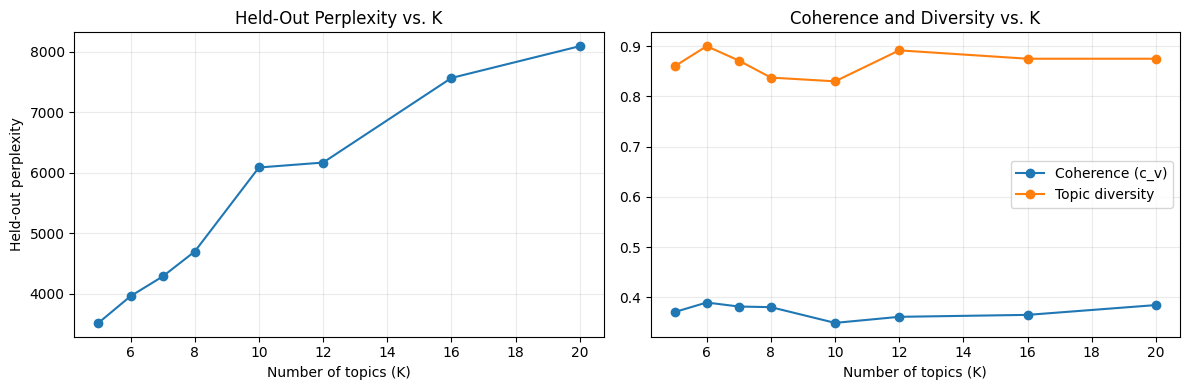

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    k_results_df["K"],
    k_results_df["perplexity_test"],
    marker="o",
)
axes[0].set_xlabel("Number of topics (K)")
axes[0].set_ylabel("Held-out perplexity")
axes[0].set_title("Held-Out Perplexity vs. K")
axes[0].grid(alpha=0.25)

axes[1].plot(
    k_results_df["K"],
    k_results_df["coherence"],
    marker="o",
    label="Coherence (c_v)",
)
axes[1].plot(
    k_results_df["K"],
    k_results_df["diversity"],
    marker="o",
    label="Topic diversity",
)
axes[1].set_xlabel("Number of topics (K)")
axes[1].set_title("Coherence and Diversity vs. K")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Topic stability check for the finalists 

In [21]:
def topic_stability(top_words_a, top_words_b):
    """
    For each topic in run A, find the best-matching topic in run B.

    Matching is based on Jaccard similarity between the two top-word sets.
    Returns the mean best-match score across topics in run A.
    """
    scores = []

    for words_a in top_words_a:
        set_a = set(words_a)

        best_score = max(
            len(set_a & set(words_b)) / len(set_a | set(words_b))
            for words_b in top_words_b
        )

        scores.append(best_score)

    return float(np.mean(scores))


stability_results = []

for k in sorted(FINALIST_K):
    original_model = candidate_models[k]

    original_top_words = get_top_words(
        original_model.components_,
        count_terms,
        n_top_words=N_TOP_WORDS,
    )

    alternate_seed_model = LatentDirichletAllocation(
        n_components=k,
        doc_topic_prior=DOC_TOPIC_PRIOR,
        topic_word_prior=TOPIC_WORD_PRIOR,
        learning_method="batch",
        random_state=123,
        n_jobs=-1,
    )

    alternate_seed_model.fit(X_counts_train)

    alternate_top_words = get_top_words(
        alternate_seed_model.components_,
        count_terms,
        n_top_words=N_TOP_WORDS,
    )

    stability = topic_stability(
        original_top_words,
        alternate_top_words,
    )

    stability_results.append(
        {
            "K": k,
            "stability": stability,
        }
    )

    print(f"K={k}: average best-match Jaccard stability = {stability:.3f}")

stability_results_df = pd.DataFrame(stability_results)

display(stability_results_df)

K=5: average best-match Jaccard stability = 0.283
K=6: average best-match Jaccard stability = 0.286
K=10: average best-match Jaccard stability = 0.190
K=12: average best-match Jaccard stability = 0.143


,K,stability
0,5,0.282540
1,6,0.285685
2,10,0.189740
3,12,0.142680


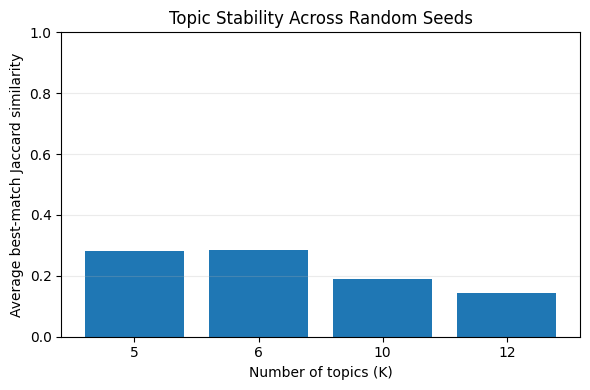

In [22]:
# Optional stability comparison plot

plt.figure(figsize=(6, 4))

plt.bar(
    stability_results_df["K"].astype(str),
    stability_results_df["stability"],
)

plt.xlabel("Number of topics (K)")
plt.ylabel("Average best-match Jaccard similarity")
plt.title("Topic Stability Across Random Seeds")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Select the final topic count

In [23]:
# Based on the balance among:
# - held-out perplexity
# - coherence
# - topic diversity
# - redundant-topic checks
# - stability across random seeds
# - interpretability of the resulting topics
#
# K=10 is retained as the more stable and interpretable solution.
N_TOPICS_LDA = 5

# Reuse the already-fitted K=10 model from the grid search.
lda = candidate_models[N_TOPICS_LDA]

print(f"Selected final number of topics: K={N_TOPICS_LDA}")

Selected final number of topics: K=5


## Inspect the final model's top words

In [24]:
lda_top_words = get_top_words(
    lda.components_,
    count_terms,
    n_top_words=N_TOP_WORDS,
)

for topic_index, words in enumerate(lda_top_words):
    print(f"Topic {topic_index}: {', '.join(words)}")

Topic 0: funny, kids, laugh, jokes, humor, hilarious, sex, laughs, friends, family
Topic 1: disney, wedding, picture, high, school, woman, women, relatively, girls, friends
Topic 2: boring, sex, looks, worse, horror, women, money, interesting, science, men
Topic 3: book, horror, read, special, effects, novel, version, interesting, second, brilliant
Topic 4: music, true, romantic, family, performances, beautiful, place, takes, interesting, wife


## Transform the full corpus

In [70]:
# The vectorizer has already been fitted on the training split.
# Apply that same vocabulary to the full corpus.
X_counts_full = count_vectorizer.transform(df["topic_text"])

# Each row is a document and each column is a topic probability.
doc_topic_lda = lda.transform(X_counts_full)

print("Full document-term matrix:", X_counts_full.shape)
print("Document-topic matrix:", doc_topic_lda.shape)

# Verify that each document's topic probabilities sum to approximately 1.
print(
    "Topic-mixture row sums:",
    doc_topic_lda.sum(axis=1).min(),
    "to",
    doc_topic_lda.sum(axis=1).max(),
)

Full document-term matrix: (2000, 2233)
Document-topic matrix: (2000, 5)
Topic-mixture row sums: 0.9999999999999997 to 1.0000000000000004


## Evaluate the final selected model 

In [71]:
# Held-out model-fit metrics
test_perplexity = lda.perplexity(X_counts_test)
test_loglik = lda.score(X_counts_test)

# Topic-quality metrics
#
# Use the full coherence function here for the final model, assuming
# coherence_c_v() was defined earlier in the notebook.
lda_coherence = coherence_c_v(lda_top_words)
lda_diversity = topic_diversity(lda_top_words)
lda_redundant = redundant_pairs(lda_top_words)

print(f"Held-out perplexity: {test_perplexity:.1f}")
print(f"Held-out log-likelihood: {test_loglik:.1f}")
print(f"LDA coherence (c_v): {lda_coherence:.3f}")
print(f"LDA topic diversity: {lda_diversity:.3f}")

if lda_redundant:
    print("\nRedundant topic pairs (>=5 shared top words):")

    for topic_i, topic_j, shared_words in lda_redundant:
        print(
            f"  Topic {topic_i} <-> Topic {topic_j}: "
            f"{shared_words}"
        )
else:
    print("\nNo redundant topic pairs at the 5-word-overlap threshold.")

Held-out perplexity: 3615.3
Held-out log-likelihood: -164096.4
LDA coherence (c_v): 0.374
LDA topic diversity: 0.880

No redundant topic pairs at the 5-word-overlap threshold.


## Inspect one documents full topic mixture

In [72]:
example_position = 0

mixture = pd.Series(
    doc_topic_lda[example_position],
    index=[
        f"topic_{topic_index}"
        for topic_index in range(N_TOPICS_LDA)
    ],
)

print(df["topic_text"].iloc[example_position][:200], "...\n")
print(mixture.sort_values(ascending=False))

i wish there were more comedies like that - crossing over the political correctness line , but not over the line of good taste , so as to make a movie hard to watch.the film is quite pointy , it is fo ...

topic_2    0.684801
topic_0    0.271435
topic_4    0.014645
topic_3    0.014627
topic_1    0.014491
dtype: float64


In [73]:
# Read representative listings alongside the top-word lists before assigning
# human-readable labels.

TOPIC_TO_INSPECT = 0

for text, weight in representative_docs(
    doc_topic_lda,
    TOPIC_TO_INSPECT,
    df["topic_text"].tolist(),
):
    print(f"P(topic {TOPIC_TO_INSPECT} | document) = {weight:.2f}")
    print(text[:300])
    print("---")

P(topic 0 | document) = 0.99
this version of " doctor dolittle " came into stores back when i was twelve years old , which was when i first it . i think i liked it a lot at the time , and watched it again a few months later . after many years , i just decided to check it out again . since i am obviously not as easily amused as 
---
P(topic 0 | document) = 0.98
let us ... you are watching a movie starring and co - written by . you are obviously not expecting something with depth and plausibility . but he is a talented comedian , and anyone who is an avid snl has seen perform some very funny skits . he is not berle , but he has that mindlessly funny comic e
---
P(topic 0 | document) = 0.98
a general nasty tone to this comedy prevented me from rating this a " 9 " or a " 10 , " but it does have a ton of laughs , courtesy of . he is at is best when he is at the dinner table playing everyone but the kid . that is one of the funniest scenes i remember from any 1990s comedy . his humor is v
--

### Assign Topic Labels

In [25]:
lda_topic_labels = {
    0: "Comedy and Family Entertainment",
    1: "Disney and Family",
    2: "Negative Sentiment",
    3: "Horror and Book to Film Adaptations",
    4: "Romantic Drama",
    
  
}

assert len(lda_topic_labels) == N_TOPICS_LDA
assert set(lda_topic_labels) == set(range(N_TOPICS_LDA))

for topic_index, label in lda_topic_labels.items():
    print(
        f"Topic {topic_index}: {label}\n"
        f"  Top words: {', '.join(lda_top_words[topic_index])}"
    )

Topic 0: Comedy and Family Entertainment
  Top words: funny, kids, laugh, jokes, humor, hilarious, sex, laughs, friends, family
Topic 1: Disney and Family
  Top words: disney, wedding, picture, high, school, woman, women, relatively, girls, friends
Topic 2: Negative Sentiment
  Top words: boring, sex, looks, worse, horror, women, money, interesting, science, men
Topic 3: Horror and Book to Film Adaptations
  Top words: book, horror, read, special, effects, novel, version, interesting, second, brilliant
Topic 4: Romantic Drama
  Top words: music, true, romantic, family, performances, beautiful, place, takes, interesting, wife


### LDA VISUALIZATION

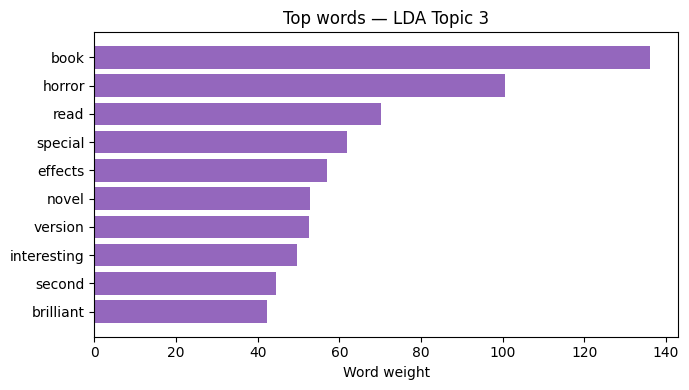

In [26]:
topic_to_plot = 3
words = lda_top_words[topic_to_plot]
weights = [lda.components_[topic_to_plot][count_vectorizer.vocabulary_[w]] for w in words]

plt.figure(figsize=(7, 4))
plt.barh(words[::-1], weights[::-1], color="tab:purple")
plt.title(f"Top words — LDA Topic {topic_to_plot}")
plt.xlabel("Word weight")
plt.tight_layout()
plt.show()

In [27]:
# Interactive intertopic distance map. In Colab this renders inline;
# pyLDAvis.save_html(panel, "lda_vis.html") to export it separately.
panel = pyLDAvis.lda_model.prepare(lda, X_counts_train, count_vectorizer, mds="tsne")
pyLDAvis.display(panel)

## NMF with SciKit Learn

In [37]:
# NMF factors TF-IDF weighted input, not raw counts.
tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=10,stop_words = list(domain_stopwords))
X_tfidf = tfidf_vectorizer.fit_transform(df["topic_text"])
tfidf_terms = tfidf_vectorizer.get_feature_names_out()

N_TOPICS_NMF = 5

nmf = NMF(n_components=N_TOPICS_NMF, init="nndsvda", random_state=RANDOM_STATE, max_iter=400)
W = nmf.fit_transform(X_tfidf)   # document-topic
H = nmf.components_              # topic-term

print("W (doc-topic):", W.shape, " H (topic-term):", H.shape)

W (doc-topic): (2000, 5)  H (topic-term): (5, 2783)


In [38]:
nmf_top_words = get_top_words(H, tfidf_terms, n_top_words=10)
for k, words in enumerate(nmf_top_words):
    print(f"Topic {k}: {', '.join(words)}")

Topic 0: woman, sex, romantic, women, relationship, school, performances, high, comes, beautiful
Topic 1: funny, laugh, jokes, humor, hilarious, laughing, romantic, 10, loud, laughs
Topic 2: book, read, loved, books, novel, reading, fantastic, amazing, moon, beautiful
Topic 3: horror, 10, effects, waste, low, budget, money, boring, special, interesting
Topic 4: disney, music, family, songs, kids, musical, children, loved, animation, song


In [39]:
TOPIC_TO_INSPECT = 0
for text, weight in representative_docs(W, TOPIC_TO_INSPECT, df["topic_text"].tolist()):
    print(f"W[doc, topic {TOPIC_TO_INSPECT}] = {weight:.3f}")
    print(text[:300], "\n---")

W[doc, topic 0] = 0.123
regardless of how cyberspace has seemingly diminished it is size , the world is still an awfully big place , and it is impossible for any one person to occupy more than a minuscule portion of it at any given time . so it is imperative that individuals find that special niche for themselves , that li 
---
W[doc, topic 0] = 0.119
when i finished watching this film last night i had tears down my face and was helpless to my own pondering about what this film was showing . the last time i was so invested in characters in a rom - com was " when met " but even though the film was not as artistically proficient , it still impacted 
---
W[doc, topic 0] = 0.116
the seduction and hypnosis of a haynes film is hard to . his attention to detail in such films like " far from heaven " and " i am not there " are simply superb , and one can not overlook the vision he engulfs upon as he directs each one of them . in his newest venture , " , " which is based on the  
---


In [41]:
# EDIT THIS after inspecting nmf_top_words above.
# nmf_topic_labels = {k: f"Topic {k}" for k in range(N_TOPICS_NMF)}

nmf_topic_labels = {
    0: "Romantic/Relationship Drama",
    1: "Comedy",
    2: "Book Adaptations",
    3: "Horror",
    4: "Family and Musicals",}


## Evaluating 

In [42]:
nmf_reconstruction_err = nmf.reconstruction_err_
nmf_coherence = coherence_c_v(nmf_top_words)
nmf_diversity = topic_diversity(nmf_top_words)

print(f"NMF reconstruction error: {nmf_reconstruction_err:.2f}")
print(f"NMF coherence (c_v): {nmf_coherence:.3f}")
print(f"NMF topic diversity: {nmf_diversity:.3f}")

# Reminder from the lecture: reconstruction error nearly always improves as K
# grows, exactly like perplexity did for LDA — never choose K from this number alone.
nmf_redundant = redundant_pairs(nmf_top_words)
print(f"\nRedundant topic pairs: {len(nmf_redundant)}")

NMF reconstruction error: 43.83
NMF coherence (c_v): 0.520
NMF topic diversity: 0.920

Redundant topic pairs: 0
